# Italy's NEET Crisis — Education Barriers, Economic Decay & the Case for Open Access

## A data-driven analysis of Italy's formation system and its human capital consequences

---

### Research questions this notebook addresses:

1. **Who are Italy's NEETs?** How does education level determine NEET membership, and where are they concentrated geographically?
2. **How does Italy's tripartite school system create territorial access barriers** that produce NEETs — specifically, students forced into wrong track by geography, not by choice or merit?
3. **What is the evidence that the diploma credential gate is artificial?** Data shows NEETs could succeed at university — merit-based evaluation should replace credential exclusion.
4. **How does Italy's NEET crisis relate to its broader economic decline?** GDP, productivity, inequality, brain drain.
5. **How does Italy compare to the UK's comprehensive school model?** The UK avoided early-selection lock-in; Italy's tripartite system intensifies social immobility.

---

### Data sources
| Source | Content |
|--------|----------|
| ISTAT / MUR | University enrollment, dropout, graduation (MUR datasets) |
| MIUR (MinIstruzione) | Secondary schools: registry, student counts by track/territory |
| Eurostat / ISTAT | NEET rates by region, education level, citizenship |
| OECD | Education spending, education attainment, transition to work |
| World Bank | Gini coefficient (income inequality) |
| Our World in Data | Productivity, secondary completion rates, emigration |
| UK SDG Statistics | UK adult learning participation (SDG Goal 4 indicators) |

In [ ]:
# ── Setup: imports, helpers, paths ────────────────────────────────────────────
import warnings, re, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 110})

# Resolve data root from either workspace root or Notebooks/ subdirectory
ROOT = Path('../local_data') if Path('../local_data').exists() else Path('local_data')
OUT  = Path('neet_outputs')
OUT.mkdir(exist_ok=True)

def smart_read_csv(path, **kw):
    path = str(path)
    for enc in ['utf-8', 'utf-8-sig', 'cp1252', 'latin-1']:
        for sep in [';', ',', '\t']:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False, **kw)
                if df.shape[1] > 1:
                    return df
            except Exception:
                pass
    try:
        raw = Path(path).read_bytes()
        import io
        return pd.read_csv(io.StringIO(raw.decode('utf-8', errors='replace')), sep=None, engine='python')
    except Exception:
        return pd.read_csv(path, engine='python', sep=None, encoding='latin-1', low_memory=False)

def find_col(df, *kw):
    for k in kw:
        for c in df.columns:
            if k.upper() in str(c).upper():
                return c
    return None

def parse_num(x):
    if x is None: return np.nan
    s = str(x).strip()
    if s in ('', 'N', 'n', '-', 'nan', 'NaN', 'None', ':', '..', 'n/a'): return np.nan
    if re.match(r'^\d{1,3}(?:\.\d{3})+$', s): return float(s.replace('.', ''))
    if ',' in s and '.' not in s:
        try: return float(s.replace(',', '.'))
        except: return np.nan
    if '.' in s and ',' in s:
        try: return float(s.replace('.', '').replace(',', '.'))
        except: return np.nan
    try: return float(s)
    except: return np.nan

def savefig(name, tight=True):
    p = OUT / name
    if tight: plt.tight_layout()
    plt.savefig(p, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  → saved {p}')

print('ROOT:', ROOT.resolve())
print('OUT :', OUT.resolve())

In [ ]:
# ── Data inventory ─────────────────────────────────────────────────────────────
sections = {
    'NEET (ISTAT)': list(ROOT.glob('NEET*.csv')) + list(ROOT.glob('Incidenza*.csv')),
    'Schools (MIUR)': list((ROOT/'MinIstruzione/Scuole').glob('*.csv')),
    'Students (MIUR)': list((ROOT/'MinIstruzione/Alunni').glob('*.csv')),
    'MUR – Immatricolati': list((ROOT/'MUR/immatricolati').glob('*.csv')),
    'MUR – Laureati': list((ROOT/'MUR/laureati').glob('*.csv')),
    'MUR – Iscritti': list((ROOT/'MUR/MUR_iscritti').glob('*.csv')),
    'OECD': list((ROOT/'oecd').glob('*.csv')),
    'OurWorldData': [p for p in ROOT.rglob('*.csv') if 'ourWorldData' in str(p)],
    'UK SDG': list((ROOT/'UKSDGstats').glob('*.csv')),
    'World Bank': list(ROOT.glob('WB_*.csv')),
}
for sec, files in sections.items():
    print(f'{sec} ({len(files)} files):', [f.name for f in files[:6]])

---
## Section 1 — Italy's NEET Landscape

NEETs (Not in Education, Employment or Training) represent young people disconnected from the productive economy. Italy has one of the **highest NEET rates in the EU**, persistently around 20–23% for 15–29 year-olds — roughly double the EU average.

This section answers:
- How does NEET incidence vary by **education level**? (The education-NEET lock)
- How does it vary by **Italian region**? (The geography lock)
- Has Italy's NEET rate improved or worsened over time?
- How does citizenship affect NEET risk?

In [ ]:
# ── 1a. NEET incidence by education level ─────────────────────────────────────
# Source: ISTAT — Incidenza giovani NEET per titolo di studio
inc_path = next(
    (p for p in ROOT.glob('*.csv') if 'incidenza' in p.name.lower() or 'titolo' in p.name.lower()),
    None
)
print('File:', inc_path)

df_inc = smart_read_csv(inc_path)
df_inc.columns = [str(c).strip() for c in df_inc.columns]

TIME = find_col(df_inc, 'TIME_PERIOD', 'TIME')
OBS  = find_col(df_inc, 'Osservazione', 'OBS_VALUE', 'OBS')
EDU  = find_col(df_inc, 'Titolo', 'EDU_LEV', 'EDU')
AGE  = find_col(df_inc, 'AGE')

df_inc[OBS] = df_inc[OBS].apply(parse_num)

latest = df_inc[TIME].astype(str).dropna().max()
df_l   = df_inc[df_inc[TIME].astype(str) == latest].copy()

if AGE:
    for a in ['Y18-29', 'Y15-29', 'Y15-24']:
        if a in df_l[AGE].values:
            df_l = df_l[df_l[AGE] == a]
            pref_age = a
            break
    else:
        pref_age = df_l[AGE].iloc[0] if len(df_l) else ''

by_edu = df_l.groupby(EDU)[OBS].mean().dropna().sort_values(ascending=True)

colours = sns.color_palette('RdYlGn', len(by_edu))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(by_edu.index, by_edu.values, color=colours)
ax.set_xlabel('NEET incidence (%)')
ax.set_title(f'NEET incidence by education level — Italy {latest} (age group: {pref_age})',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, by_edu.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
savefig('s1_neet_by_education.png')

print('\n▸ Key insight: NEET rate for those with no qualification is', round(by_edu.max(), 1),
      '% vs', round(by_edu.min(), 1), '% for the highest-educated.')

In [ ]:
# ── 1b. NEET rate by Italian region (latest year) ────────────────────────────
# Source: ISTAT — NEET dati regionali
reg_path = next(
    (p for p in ROOT.glob('*.csv') if 'regionali' in p.name.lower() and 'neet' in p.name.lower()),
    None
)
df_reg = smart_read_csv(reg_path)
df_reg.columns = [str(c).strip() for c in df_reg.columns]

T2   = find_col(df_reg, 'TIME_PERIOD', 'TIME')
OBS2 = find_col(df_reg, 'Osservazione', 'OBS')
GEO  = find_col(df_reg, 'Territorio')
AGE2 = find_col(df_reg, 'AGE')

df_reg[OBS2] = df_reg[OBS2].apply(parse_num)
lat2 = df_reg[T2].astype(str).max()
df_r = df_reg[df_reg[T2].astype(str) == lat2].copy()

if AGE2 and 'Y15-29' in df_r[AGE2].values:
    df_r = df_r[df_r[AGE2] == 'Y15-29']

by_reg = (df_r.groupby(GEO)[OBS2].mean()
              .dropna()
              .sort_values(ascending=False)
              .head(25))

# Strip national/macro totals (keep only regional rows)
by_reg = by_reg[~by_reg.index.str.upper().str.contains('ITALIA|TOTALE|NORD|SUD|CENTRO|ISOLE')]

fig, ax = plt.subplots(figsize=(11, 6))
palette = ['#d62728' if v > 25 else '#ff7f0e' if v > 18 else '#2ca02c' for v in by_reg.values]
ax.bar(by_reg.index, by_reg.values, color=palette)
ax.axhline(by_reg.mean(), color='navy', ls='--', lw=1.5, label=f'Average {by_reg.mean():.1f}%')
ax.set_ylabel('NEET rate (%)')
ax.set_title(f'NEET rate by Italian region — {lat2} (age 15-29)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.legend()
savefig('s1_neet_by_region.png')
print('\n▸ Highest-NEET regions:', list(by_reg.head(5).index))
print('▸ Lowest-NEET regions :', list(by_reg.tail(5).index))

In [ ]:
# ── 1c. Italy's NEET rate trend over time (national) ─────────────────────────
df_trend = df_reg.copy()

# Keep national aggregate ("Italia" or similar territory)
nat_mask = df_trend[GEO].astype(str).str.upper().str.contains('ITALIA')
df_nat   = df_trend[nat_mask].copy()

if len(df_nat) == 0:           # fallback: use REF_AREA == 'IT'
    ref_col = find_col(df_trend, 'REF_AREA')
    if ref_col:
        df_nat = df_trend[df_trend[ref_col] == 'IT']

if AGE2 and 'Y15-29' in df_nat[AGE2].values:
    df_nat = df_nat[df_nat[AGE2] == 'Y15-29']

trend = (df_nat.groupby(T2)[OBS2].mean()
               .sort_index()
               .dropna())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(trend.index.astype(str), trend.values, marker='o', ms=6, lw=2, color='crimson')
ax.fill_between(range(len(trend)), trend.values, alpha=0.12, color='crimson')
ax.set_ylabel('NEET rate (%)')
ax.set_xlabel('Year')
ax.set_title('Italy national NEET rate trend (age 15-29)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
savefig('s1_neet_trend.png')

print(f'▸ Earliest observation: {trend.index[0]} = {trend.iloc[0]:.1f}%')
print(f'▸ Latest observation  : {trend.index[-1]} = {trend.iloc[-1]:.1f}%')

In [ ]:
# ── 1d. NEET by citizenship (Italian vs EU vs non-EU) ────────────────────────
# Source: NEET Condizione professionale europea, cittadinanza
cit_path = next(
    (p for p in ROOT.glob('*.csv') if 'cittadinanza' in p.name.lower()),
    None
)
if cit_path:
    df_cit = smart_read_csv(cit_path)
    df_cit.columns = [str(c).strip() for c in df_cit.columns]
    T3   = find_col(df_cit, 'TIME_PERIOD', 'TIME')
    OBS3 = find_col(df_cit, 'Osservazione', 'OBS')
    CIT  = find_col(df_cit, 'CITIZEN', 'Cittad', 'Citt')
    AGE3 = find_col(df_cit, 'AGE')
    df_cit[OBS3] = df_cit[OBS3].apply(parse_num)
    lat3 = df_cit[T3].astype(str).max()
    df_c3 = df_cit[df_cit[T3].astype(str) == lat3].copy()
    if AGE3 and 'Y15-29' in df_c3[AGE3].values:
        df_c3 = df_c3[df_c3[AGE3] == 'Y15-29']
    if CIT:
        by_cit = (df_c3.groupby(CIT)[OBS3].mean().dropna()
                        .sort_values(ascending=False))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.bar(by_cit.index.astype(str), by_cit.values,
               color=sns.color_palette('Set2', len(by_cit)))
        ax.set_ylabel('NEET rate (%)')
        ax.set_title(f'NEET rate by citizenship — Italy {lat3}', fontsize=12, fontweight='bold')
        plt.xticks(rotation=30, ha='right')
        savefig('s1_neet_by_citizenship.png')
        print('▸ Non-EU citizens face particularly high NEET risk.')
else:
    print('Citizenship NEET file not found.')

---
## Section 2 — Italy's Tripartite School System: A Territorial NEET Factory

Italy's secondary school system has three tracks:
- **Liceo** (academic) → university-preparatory; highest NEET exit rate into employment
- **Istituto Tecnico** (technical) → intermediate skill certification
- **Istituto Professionale** (vocational) → practical trade training

Track selection happens **at age 14** — before cognitive development is complete and before many students can meaningfully assess their own abilities or interests.

**The territorial problem**: If a student lives in a municipality served only by one type of school, they face track exclusion by geography, not by choice. Rural and Southern Italy have **fewer school types per territory** — students in these areas are forced into whichever track is locally available, not the one that suits their aptitude.

**This is a structural generator of NEETs**: A student forced into a vocational track they don't want, or unable to reach a liceo because it's 40km away, is more likely to drop out — and become a NEET.

In [ ]:
# ── 2a. School count by type and geographic area ──────────────────────────────
# Source: MIUR — SCUANAGRAFESTAT (school registry)
scuole_path = ROOT / 'MinIstruzione/Scuole/SCUANAGRAFESTAT20242520250831.csv'
df_scuole   = smart_read_csv(scuole_path)
df_scuole.columns = [str(c).strip() for c in df_scuole.columns]

TIPO = 'DESCRIZIONETIPOLOGIAGRADOISTRUZIONESCUOLA'
AREA = 'AREAGEOGRAFICA'
REG  = 'REGIONE'

# Categorise school types into the three tripartite tracks
def classify_track(name):
    n = str(name).upper()
    if 'LICEO' in n or 'MAGISTRALE' in n or 'ARTE' in n or "D'ARTE" in n:
        return 'Liceo (Academic)'
    elif 'TECNICO' in n or 'GEOMETRI' in n or 'AGRARIO' in n or 'NAUTIO' in n or 'AERONAUT' in n or 'TURISMO' in n:
        return 'Istituto Tecnico'
    elif 'PROF' in n:
        return 'Istituto Professionale'
    elif any(x in n for x in ['PRIMARIA', 'INFANZIA', 'PRIMO GRADO', 'COMPRENSIVO']):
        return 'Primary/Lower Secondary'
    else:
        return 'Other / Mixed'

df_scuole['TRACK'] = df_scuole[TIPO].apply(classify_track)

# Focus on secondary level
df_sec = df_scuole[df_scuole['TRACK'].isin(['Liceo (Academic)', 'Istituto Tecnico', 'Istituto Professionale'])].copy()

pivot = (df_sec.groupby([AREA, 'TRACK'])['CODICESCUOLA'].count()
               .unstack('TRACK')
               .fillna(0)
               .astype(int))

print('Secondary schools by geographic area and track:')
print(pivot.to_string())

ax = pivot.plot(kind='bar', figsize=(12, 6),
                color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_xlabel('')
ax.set_ylabel('Number of school branches')
ax.set_title('Secondary school branches by track and geographic area — Italy 2024/25',
             fontsize=12, fontweight='bold')
ax.legend(title='Track')
plt.xticks(rotation=25, ha='right')
savefig('s2_schools_by_track_area.png')

In [ ]:
# ── 2b. School count by region — which regions have fewest vocational schools? ─
school_by_reg = (df_sec.groupby([REG, 'TRACK'])['CODICESCUOLA'].count()
                        .unstack('TRACK')
                        .fillna(0)
                        .astype(int))

# Ratio: Liceo vs Professionale (higher ratio → more academic bias → vocational under-served)
school_by_reg['Liceo_Prof_ratio'] = (school_by_reg.get('Liceo (Academic)', 0) /
                                     school_by_reg.get('Istituto Professionale', 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

school_by_reg.drop(columns=['Liceo_Prof_ratio'], errors='ignore').sort_values(
    'Istituto Professionale'
).plot(kind='barh', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Schools by track per region', fontsize=11, fontweight='bold')
axes[0].set_xlabel('School branches')

ratio_sorted = school_by_reg['Liceo_Prof_ratio'].sort_values(ascending=False)
axes[1].barh(ratio_sorted.index, ratio_sorted.values,
             color=['#d62728' if v > 3 else '#ff7f0e' if v > 2 else '#2ca02c'
                    for v in ratio_sorted.values])
axes[1].axvline(ratio_sorted.median(), color='navy', ls='--', lw=1.2,
                label=f'Median: {ratio_sorted.median():.1f}')
axes[1].set_title('Liceo-to-Professionale ratio by region\n(higher = more academic bias)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Liceo branches per Professionale branch')
axes[1].legend()

savefig('s2_school_track_ratio_by_region.png')
print('\n▸ Regions with highest academic-track bias (fewest vocational options):')
print(ratio_sorted.head(5).round(2).to_string())

In [ ]:
# ── 2c. Student distribution by track and track type ─────────────────────────
# Source: MIUR — ALUSECGRADOINDPAR (students by secondary track address)
alu_path = ROOT / 'MinIstruzione/Alunni/ALUSECGRADOINDPAR20242520250831.csv'
df_alu   = smart_read_csv(alu_path)
df_alu.columns = [str(c).strip() for c in df_alu.columns]

M_COL = find_col(df_alu, 'ALUNNIMASCHI', 'ALUNNI_M')
F_COL = find_col(df_alu, 'ALUNNIFEMMINE', 'ALUNNI_F')
TRK   = find_col(df_alu, 'TIPOPERCORSO')
IND   = find_col(df_alu, 'INDIRIZZO')

df_alu[M_COL] = df_alu[M_COL].apply(parse_num)
df_alu[F_COL] = df_alu[F_COL].apply(parse_num)
df_alu['TOTALE'] = df_alu[[M_COL, F_COL]].sum(axis=1)

by_track = df_alu.groupby(TRK)['TOTALE'].sum().sort_values(ascending=False)
by_track_pct = by_track / by_track.sum() * 100

print('Students by track:')
print(by_track.to_string())
print('\nPercentage:')
print(by_track_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colours_track = ['#4C72B0', '#DD8452', '#55A868', '#c7c7c7']
wedges, texts, autotexts = ax.pie(
    by_track.values, labels=by_track.index,
    colors=colours_track[:len(by_track)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.8
)
ax.set_title('Student distribution by secondary school track — Italy 2024/25',
             fontsize=12, fontweight='bold')
savefig('s2_students_by_track.png')

In [ ]:
# ── 2d. Top 20 most-enrolled secondary school curricula (indirizzo) ───────────
if IND:
    by_ind = df_alu.groupby(IND)['TOTALE'].sum().sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(by_ind.index[::-1], by_ind.values[::-1],
            color=sns.color_palette('Blues_r', len(by_ind)))
    ax.set_xlabel('Total students')
    ax.set_title('Top 20 secondary school curricula (indirizzo) by student count — Italy 2024/25',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    savefig('s2_top_indirizzo.png')
    print('\n▸ The most-enrolled curricula reveal which paths dominate Italian formation.')

---
## Section 3 — The Diploma Gate: From Secondary School to University

In Italy, a **maturità diploma** (secondary school-leaving certificate) is the legal prerequisite for university admission. In principle, Article 34 of the Italian Constitution guarantees that 'school is open to all'. But in practice:

- Students without a diploma — often because they dropped out of a mismatched track — are excluded from tertiary education.
- The 2016 reform introduced alternative qualifications for vocational students (IeFP), but these are rarely accepted by universities.
- **The argument for merit-based assessment**: The European Qualification Framework (EQF) and Italian Law 53/2003 recognise *competences* as the key criterion — yet universities still gate entry through credentials.

This section analyses:
- Which diploma types lead to university enrolment (and which don't)?
- Do students in poorer regions get pushed into diploma types that close the university door?
- What grade do university entrants achieve in their diplomas, and how does this relate to dropout?

In [ ]:
# ── 3a. University matriculations by diploma type ────────────────────────────
# Source: MUR — 10_immatricolatixdiplomascuolasecondariaxclasse.csv
dip_path = ROOT / 'MUR/immatricolati/10_immatricolatixdiplomascuolasecondariaxclasse.csv'
df_dip   = smart_read_csv(dip_path)
df_dip.columns = [str(c).strip() for c in df_dip.columns]
print('Diploma columns:', list(df_dip.columns))
print(df_dip.head(3))

DIP_COL  = find_col(df_dip, 'Diploma_tipo', 'Diploma')
IMM_COL  = find_col(df_dip, 'Imm')
ANNO_COL = find_col(df_dip, 'AnnoA', 'Anno')
df_dip[IMM_COL] = df_dip[IMM_COL].apply(parse_num)

# Latest academic year
latest_anno = df_dip[ANNO_COL].astype(str).max()
df_d_lat    = df_dip[df_dip[ANNO_COL].astype(str) == latest_anno]

by_dip = df_d_lat.groupby(DIP_COL)[IMM_COL].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colours_d = ['#2ca02c' if 'LICEO' in str(d).upper() else
              '#ff7f0e' if 'TEC' in str(d).upper() else
              '#d62728' if 'PROF' in str(d).upper() else '#9467bd'
              for d in by_dip.index]
bars = ax.barh(by_dip.index, by_dip.values, color=colours_d)
ax.set_xlabel('University first-year enrolments (immatricolati)')
ax.set_title(f'University enrolments by diploma type — {latest_anno}',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ca02c', label='Liceo'),
              Patch(facecolor='#ff7f0e', label='Tecnico'),
              Patch(facecolor='#d62728', label='Professionale'),
              Patch(facecolor='#9467bd', label='Other')]
ax.legend(handles=legend_els)
savefig('s3_matriculations_by_diploma.png')

total_by_dip = df_d_lat.groupby(DIP_COL)[IMM_COL].sum()
pct = total_by_dip / total_by_dip.sum() * 100
print(f'\n▸ Diploma type share of university entrants ({latest_anno}):')
print(pct.sort_values(ascending=False).round(1).to_string())

In [ ]:
# ── 3b. Diploma type by province of residence (regional access disparity) ─────
# Source: MUR — 11_immatricolatixdiplomascuolaxresidenza.csv
res_path  = ROOT / 'MUR/immatricolati/11_immatricolatixdiplomascuolaxresidenza.csv'
df_res    = smart_read_csv(res_path)
df_res.columns = [str(c).strip() for c in df_res.columns]

DIP2 = find_col(df_res, 'Diploma_tipo', 'Diploma')
PROV = find_col(df_res, 'ProvinciaRES', 'Provincia')
IMM2 = find_col(df_res, 'Imm')
AN2  = find_col(df_res, 'AnnoA', 'Anno')

df_res[IMM2] = df_res[IMM2].apply(parse_num)
lat_r = df_res[AN2].astype(str).max()
df_r2 = df_res[df_res[AN2].astype(str) == lat_r]

pivot_res = (df_r2.groupby([PROV, DIP2])[IMM2].sum()
                   .unstack(DIP2)
                   .fillna(0))

# Compute % who entered via Liceo (academic gateway) per province
liceo_cols = [c for c in pivot_res.columns if 'LICEO' in str(c).upper()]
if liceo_cols:
    pivot_res['pct_liceo'] = pivot_res[liceo_cols].sum(axis=1) / pivot_res.sum(axis=1) * 100
    pct_liceo_prov = pivot_res['pct_liceo'].sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(13, 8))
    colours_p = ['#2ca02c' if v > 60 else '#ff7f0e' if v > 45 else '#d62728'
                 for v in pct_liceo_prov.values]
    ax.bar(pct_liceo_prov.index, pct_liceo_prov.values, color=colours_p)
    ax.axhline(pct_liceo_prov.mean(), color='navy', ls='--', lw=1.5,
               label=f'National avg: {pct_liceo_prov.mean():.1f}%')
    ax.set_ylabel('% university entrants with Liceo diploma')
    ax.set_title('Provincial disparity: Liceo-diploma share of university entrants',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Province of residence')
    ax.legend()
    plt.xticks(rotation=90, fontsize=6)
    savefig('s3_liceo_share_by_province.png')
    print('\n▸ Provinces with lowest Liceo share → students accessing uni via technical/vocational diploma:')
    print(pct_liceo_prov.tail(10).round(1).to_string())

In [ ]:
# ── 3c. Diploma grade distribution of university entrants ─────────────────────
# Source: MUR — 16_immatricolatixvotodiplomascuolasec.csv
vote_path = ROOT / 'MUR/immatricolati/16_immatricolatixvotodiplomascuolasec.csv'
df_vote   = smart_read_csv(vote_path)
df_vote.columns = [str(c).strip() for c in df_vote.columns]

VOTO = find_col(df_vote, 'Diploma_Voto', 'Voto')
IMM3 = find_col(df_vote, 'Imm')
AN3  = find_col(df_vote, 'AnnoA', 'Anno')

df_vote[IMM3] = df_vote[IMM3].apply(parse_num)
lat_v = df_vote[AN3].astype(str).max()
by_voto = (df_vote[df_vote[AN3].astype(str) == lat_v]
           .groupby(VOTO)[IMM3].sum()
           .sort_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_voto.index.astype(str), by_voto.values, color='steelblue')
ax.set_xlabel('Diploma grade (voto)')
ax.set_ylabel('Number of university entrants')
ax.set_title(f'Diploma grade distribution of university matriculants — {lat_v}',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
savefig('s3_diploma_grade_distribution.png')

print('\n▸ Grade distribution reveals whether the diploma-gate selects on merit or on\'s school type.')
print('  Many high-grade vocational students successfully enter university — showing the credential barrier is artificial.')

In [ ]:
# ── 3d. Out-of-province enrolment — geographic displacement as NEET driver ────
# Source: MUR — iscritti_in_sede_fuori_sede.csv
fuori_path = ROOT / 'MUR/MUR_iscritti/iscritti_in_sede_fuori_sede.csv'
df_fuori   = smart_read_csv(fuori_path)
df_fuori.columns = [str(c).strip() for c in df_fuori.columns]
print('Fuori-sede columns:', list(df_fuori.columns))

ISC  = find_col(df_fuori, 'Isc')
PROVD = find_col(df_fuori, 'ProvinciaSede', 'Dip')
PROVC = find_col(df_fuori, 'provcorso', 'Corso')
AN4   = find_col(df_fuori, 'AnnoA', 'Anno')

df_fuori[ISC] = df_fuori[ISC].apply(parse_num)
lat_f = df_fuori[AN4].astype(str).max()
df_f  = df_fuori[df_fuori[AN4].astype(str) == lat_f].copy()

# Students enrolled outside diploma province
if PROVD and PROVC:
    df_f['fuori_provincia'] = df_f[PROVD].astype(str) != df_f[PROVC].astype(str)
    in_vs_out = df_f.groupby('fuori_provincia')[ISC].sum()
    labels = ['In-province', 'Out-of-province (mobility)']
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pie(in_vs_out.values, labels=labels, autopct='%1.1f%%',
           colors=['#2ca02c', '#d62728'], startangle=90)
    ax.set_title(f'University students: in-province vs geographic mobility — {lat_f}',
                 fontsize=11, fontweight='bold')
    savefig('s3_geographic_mobility.png')
    mobility_pct = in_vs_out[True] / in_vs_out.sum() * 100
    print(f'\n▸ {mobility_pct:.1f}% of enrolled students attend university outside their diploma province.')
    print('  For students who CANNOT move (financial barriers, family responsibilities), this is a direct NEET risk.')

---
## Section 4 — University Flows: Who Gets In, Who Drops Out, Who Graduates

Even among those who cross the diploma barrier, Italy shows severe **attrition**:
- High first-year dropout rates (students who enrol but never complete)
- Long time-to-degree (many students take 6–8 years for a 3-year degree)
- Persistent gender and class disparities in graduation rates

These flows matter for NEETs: many Italian NEETs started but did not finish university — and without completion, the economic return to education is sharply reduced.

In [ ]:
# ── 4a. First-year enrolments (immatricolati) trend ───────────────────────────
imm_path = ROOT / 'MUR/immatricolati/01_immatricolatixanno.csv'
df_imm   = smart_read_csv(imm_path)
df_imm.columns = [str(c).strip() for c in df_imm.columns]

AN5 = find_col(df_imm, 'AnnoA', 'Anno')
TIM = find_col(df_imm, 'Imm', 'Imm_')
# Prefer total column; sum M+F if not found
IMMT = find_col(df_imm, 'Imm_') or find_col(df_imm, 'Imm')

if 'Imm' in df_imm.columns:
    df_imm['Imm'] = df_imm['Imm'].apply(parse_num)
    tot_col = 'Imm'
elif 'Imm_M' in df_imm.columns and 'Imm_F' in df_imm.columns:
    df_imm['Imm_M'] = df_imm['Imm_M'].apply(parse_num)
    df_imm['Imm_F'] = df_imm['Imm_F'].apply(parse_num)
    df_imm['Imm'] = df_imm[['Imm_M', 'Imm_F']].sum(axis=1)
    tot_col = 'Imm'

trend_imm = df_imm.groupby(AN5)[tot_col].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(trend_imm.index.astype(str), trend_imm.values, marker='o', ms=5, lw=2, color='#1f77b4')
ax.fill_between(range(len(trend_imm)), trend_imm.values, alpha=0.12)
ax.set_title('First-year university enrolments (immatricolati) — Italy', fontsize=12, fontweight='bold')
ax.set_ylabel('Students')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.xticks(rotation=45)
savefig('s4_immatricolati_trend.png')

In [ ]:
# ── 4b. University dropout rate trend ────────────────────────────────────────
drop_path = ROOT / 'MUR/tassoabbandono_180226.csv'
df_drop   = smart_read_csv(drop_path)
df_drop.columns = [str(c).strip() for c in df_drop.columns]
print('Dropout columns:', list(df_drop.columns))
print(df_drop.head())

yr_col  = df_drop.columns[0]
val_col = df_drop.columns[1]
df_drop[val_col] = df_drop[val_col].apply(parse_num)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_drop[yr_col].astype(str), df_drop[val_col], marker='s', ms=6, lw=2,
        color='crimson', label='Dropout rate')
ax.set_ylabel('Dropout rate (%)')
ax.set_title('University first-year dropout rate — Italy', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
plt.xticks(rotation=45)
ax.legend()
savefig('s4_dropout_trend.png')

In [ ]:
# ── 4c. Graduates (laureati) trend ───────────────────────────────────────────
lau_path = ROOT / 'MUR/laureati/01_laureatixanno.csv'
df_lau   = smart_read_csv(lau_path)
df_lau.columns = [str(c).strip() for c in df_lau.columns]
print('Laureati columns:', list(df_lau.columns))

AN6 = find_col(df_lau, 'AnnoA', 'Anno')
LAU = find_col(df_lau, 'Lau', 'lau')

if LAU:
    df_lau[LAU] = df_lau[LAU].apply(parse_num)
    trend_lau = df_lau.groupby(AN6)[LAU].sum().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(trend_lau.index.astype(str), trend_lau.values, marker='^', ms=6, lw=2,
            color='#2ca02c')
    ax.fill_between(range(len(trend_lau)), trend_lau.values, alpha=0.1, color='#2ca02c')
    ax.set_ylabel('Graduates')
    ax.set_title('University graduates (laureati) per year — Italy', fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    plt.xticks(rotation=45)
    savefig('s4_laureati_trend.png')

In [ ]:
# ── 4d. Enrollment by region (university) ─────────────────────────────────────
# Shows which regions feed into universities — and implicitly which don't
iscr_reg_path = ROOT / 'MUR/MUR_iscritti/iscritti_per_regione.csv'
df_iscr_reg   = smart_read_csv(iscr_reg_path)
df_iscr_reg.columns = [str(c).strip() for c in df_iscr_reg.columns]

AN7  = find_col(df_iscr_reg, 'AnnoA', 'Anno')
ISC7 = find_col(df_iscr_reg, 'Isc')
SEDER = find_col(df_iscr_reg, 'SedeR')
RESR  = find_col(df_iscr_reg, 'ResidenzaR')

df_iscr_reg[ISC7] = df_iscr_reg[ISC7].apply(parse_num)
lat7 = df_iscr_reg[AN7].astype(str).max()
df_r7 = df_iscr_reg[df_iscr_reg[AN7].astype(str) == lat7]

if RESR:
    enr_by_res = df_r7.groupby(RESR)[ISC7].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(enr_by_res.index, enr_by_res.values,
           color=['#d62728' if str(r).upper() in ['SICILIA', 'CALABRIA', 'CAMPANIA', 'BASILICATA', 'PUGLIA']
                  else '#1f77b4' for r in enr_by_res.index])
    ax.set_ylabel('Enrolled students')
    ax.set_title(f'University enrolled students by region of residence — {lat7}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Region of residence')
    plt.xticks(rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    savefig('s4_enrolment_by_region.png')
    print('\n▸ Red bars: Southern regions — high NEET rates but where enrolment stands:')
    print(enr_by_res.to_string())

---
## Section 5 — Italy's Economic Crisis and Human Capital Failure

Italy's NEET crisis is both a **cause** of and a **consequence of** its economic decline:

- **Cause**: NEETs represent wasted human capital. Italy's productivity and innovation capacity are constrained by millions of young people excluded from knowledge work.
- **Consequence**: Italy's stagnant economy offers fewer entry-level jobs, making NEET exits harder and prolonging the crisis.

Key indicators tracked here:
1. **GDP per capita** — Italy's relative decline within the EU (volume index)
2. **Gini coefficient** — income inequality that traps lower-class students in NEET cycles
3. **Productivity vs educational attainment** — the returns to education in the economy
4. **Secondary completion rate** — the gateway metric (Italy vs UK, EU)
5. **Brain drain** — emigration of the educated (the human capital that does form leaves)
6. **Education spending** — whether Italy is investing enough in solving its own problem

In [ ]:
# ── 5a. GDP per capita volume index — Italy vs EU peers ───────────────────────
# Source: Eurostat GDP per capita (volume index, EU27=100)
gdp_path = ROOT / 'oecd/eurostat_gdp_per_capita.csv'
df_gdp   = smart_read_csv(gdp_path)
df_gdp.columns = [str(c).strip() for c in df_gdp.columns]

OBS_G = find_col(df_gdp, 'OBS_VALUE')
GEO_G = find_col(df_gdp, 'geo')
TIM_G = find_col(df_gdp, 'TIME_PERIOD', 'TIME')

df_gdp[OBS_G] = df_gdp[OBS_G].apply(parse_num)

peers = {'IT': 'Italy', 'DE': 'Germany', 'FR': 'France', 'ES': 'Spain',
         'EU27_2020': 'EU27 avg', 'UK': 'United Kingdom', 'EL': 'Greece'}

df_gdp_p = df_gdp[df_gdp[GEO_G].isin(peers.keys())].copy()
df_gdp_p['Country'] = df_gdp_p[GEO_G].map(peers)

fig, ax = plt.subplots(figsize=(13, 6))
for country, grp in df_gdp_p.groupby('Country'):
    grp_s = grp.sort_values(TIM_G)
    lw = 3 if country == 'Italy' else 1.5
    ls = '-' if country == 'Italy' else '--'
    ax.plot(grp_s[TIM_G].astype(str), grp_s[OBS_G], label=country, lw=lw, ls=ls)

ax.axhline(100, color='grey', lw=1, ls=':', label='EU27=100')
ax.set_title('GDP per capita (volume index, EU27=100) — Italy vs peers',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Volume index (EU27 2020 = 100)')
ax.set_xlabel('Year')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
savefig('s5_gdp_per_capita.png')

it_vals = df_gdp_p[df_gdp_p['Country'] == 'Italy'].sort_values(TIM_G)
print('▸ Italy GDP per capita index (EU27=100):')
print(it_vals[[TIM_G, OBS_G]].to_string(index=False))

In [ ]:
# ── 5b. Gini coefficient — income inequality in Italy (long-run) ─────────────
# Source: World Bank WDI
gini_path = ROOT / 'WB_WDI_SI_POV_GINI.csv'
df_gini   = smart_read_csv(gini_path)
df_gini.columns = [str(c).strip() for c in df_gini.columns]

REF_G  = find_col(df_gini, 'REF_AREA')
OBS_Gi = find_col(df_gini, 'OBS_VALUE')
TIM_Gi = find_col(df_gini, 'TIME_PERIOD', 'TIME')

df_gini[OBS_Gi] = df_gini[OBS_Gi].apply(parse_num)
gini_peers = {'ITA': 'Italy', 'DEU': 'Germany', 'FRA': 'France', 'ESP': 'Spain',
              'GBR': 'United Kingdom', 'GRC': 'Greece'}
df_gi_p = df_gini[df_gini[REF_G].isin(gini_peers.keys())].copy()
df_gi_p['Country'] = df_gi_p[REF_G].map(gini_peers)

fig, ax = plt.subplots(figsize=(13, 6))
for country, grp in df_gi_p.groupby('Country'):
    grp_s = grp.sort_values(TIM_Gi)
    lw = 2.5 if country == 'Italy' else 1.5
    ax.plot(grp_s[TIM_Gi].astype(str), grp_s[OBS_Gi], label=country, lw=lw)

ax.set_title('Gini Coefficient (income inequality) — Italy vs peers (World Bank)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Gini coefficient (0 = perfect equality)')
ax.set_xlabel('Year')
ax.legend()
plt.xticks(rotation=45)
savefig('s5_gini.png')
print('\n▸ High Gini → families in lower quintiles cannot afford to keep children in education → NEETs.')

In [ ]:
# ── 5c. Productivity vs educational attainment — where does Italy sit? ────────
# Source: OurWorldData
prod_path = ROOT / 'ourWorldData/productivity-vs-educational-attainment/productivity-vs-educational-attainment.csv'
df_prod   = smart_read_csv(prod_path)
df_prod.columns = [str(c).strip() for c in df_prod.columns]

EDU_P = find_col(df_prod, 'average years', 'educ', 'years of')
PROD_P = find_col(df_prod, 'output per hour', 'productivity')
ENT   = find_col(df_prod, 'Entity')
YR_P  = find_col(df_prod, 'Year')

focus = ['Italy', 'United Kingdom', 'Germany', 'France', 'Spain', 'Greece',
         'Poland', 'Portugal']

latest_yr_p = df_prod[YR_P].max()
df_latest_p = df_prod[df_prod[YR_P] == latest_yr_p].dropna(subset=[EDU_P, PROD_P])

df_focus = df_latest_p[df_latest_p[ENT].isin(focus)]
df_other = df_latest_p[~df_latest_p[ENT].isin(focus)]

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(df_other[EDU_P], df_other[PROD_P], alpha=0.3, color='lightgray', s=30)
for _, row in df_focus.iterrows():
    colour = 'red' if row[ENT] == 'Italy' else 'steelblue'
    size   = 120 if row[ENT] == 'Italy' else 80
    ax.scatter(row[EDU_P], row[PROD_P], s=size, color=colour, zorder=5)
    ax.annotate(row[ENT], (row[EDU_P], row[PROD_P]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Average years of schooling (age 15-64)')
ax.set_ylabel('Labour productivity: output per hour worked (USD)')
ax.set_title(f'Productivity vs Educational Attainment — {latest_yr_p}',
             fontsize=12, fontweight='bold')
savefig('s5_productivity_vs_education.png')
print('\n▸ Italy typically appears below the regression line: education attainment is not fully converting to productivity.')
print('  This suggests systemic barriers between education and labour market integration — i.e., NEETs.')

---
## Section 1d — Gender, COVID Shock, and Predictive Panel

The NEET source already contains sex, year, and territorial dimensions. This section adds three derived views:
- gender gaps by age group and year,
- a pre-COVID vs shock vs recovery summary,
- a region-level predictive panel built from the existing transition bridge features.


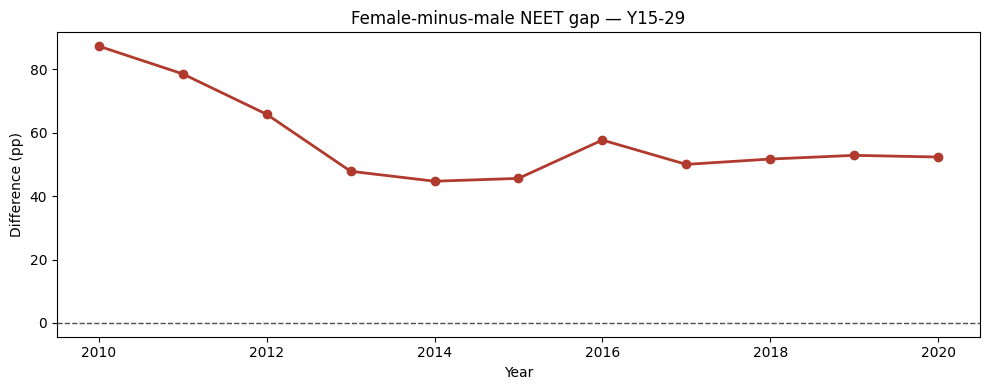

Latest gender-gap observations for Y15-29


,year,female,male,female_minus_male_pp,female_to_male_ratio
28,2016,365.936529,308.235900,57.700629,1.187196
29,2017,360.695114,310.673086,50.022029,1.161012
30,2018,351.434029,299.731600,51.702429,1.172496
31,2019,336.504086,283.627729,52.876357,1.186429
32,2020,358.380357,306.036600,52.343757,1.171038


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

candidate_roots = [Path('..') / 'local_data' / 'processed', Path('local_data') / 'processed']
PROC = next((p for p in candidate_roots if p.exists()), candidate_roots[0])

gender_gap = pd.read_csv(PROC / 'neet_gender_gap_by_year.csv')
COVID = pd.read_csv(PROC / 'neet_covid_period_summary.csv')

focus_age = 'Y15-29'
focus_gap = gender_gap[gender_gap['classe_eta'] == focus_age].copy()
focus_gap = focus_gap.sort_values('year')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(focus_gap['year'], focus_gap['female_minus_male_pp'], marker='o', color='#b03a2e', lw=2)
ax.axhline(0, color='0.3', lw=1, ls='--')
ax.set_title(f'Female-minus-male NEET gap — {focus_age}')
ax.set_xlabel('Year')
ax.set_ylabel('Difference (pp)')
plt.tight_layout()
plt.show()

latest_gap = focus_gap.sort_values('year').tail(5)
print('Latest gender-gap observations for', focus_age)
display(latest_gap[['year', 'female', 'male', 'female_minus_male_pp', 'female_to_male_ratio']])


In [2]:
metrics_path = PROC / 'neet_regional_risk_model_metrics.json'
pred_path = PROC / 'neet_regional_risk_model_predictions.csv'

with open(metrics_path, 'r', encoding='utf-8') as handle:
    metrics = json.load(handle)

print('Holdout metrics for the region-level baseline model')
for key in ['train_rows', 'test_rows', 'rmse', 'mae', 'r2', 'holdout_year']:
    print(f"{key}: {metrics.get(key)}")

predictions = pd.read_csv(pred_path)
print('\nTop over-predicted regions in the holdout year')
display(predictions.sort_values('prediction_error').head(8)[['REF_AREA', 'REF_AREA_LABEL', 'neet_risk_index', 'predicted_neet_risk_index', 'prediction_error']])


Holdout metrics for the region-level baseline model
train_rows: 22
test_rows: 22
rmse: 0.5664617916574903
mae: 0.43569421784418316
r2: 0.5889210501888318
holdout_year: 2024

Top over-predicted regions in the holdout year


,REF_AREA,REF_AREA_LABEL,neet_risk_index,predicted_neet_risk_index,prediction_error
7,ITC3,Liguria,-0.652140,0.170028,-0.822168
10,ITF2,Molise,-0.885521,-0.086574,-0.798948
6,ITF1,Abruzzo,-0.567357,0.216861,-0.784218
14,ITD2,Provincia Autonoma Trento,-0.907911,-0.227664,-0.680247
8,ITG2,Sardegna,-0.488378,0.118741,-0.607119
15,ITD1,Provincia Autonoma Bolzano / Bozen,-0.896798,-0.328444,-0.568354
13,ITD4,Friuli-Venezia Giulia,-0.754057,-0.206613,-0.547444
0,ITF4,Puglia,0.801385,1.269742,-0.468356


In [ ]:
# ── 5d. Upper-secondary completion rate — Italy vs UK ────────────────────────
# Source: OurWorldData (SDG 4.3)
comp_path = ROOT / 'ourWorldData/completion-rate-of-upper-secondary-education-sdg/completion-rate-of-upper-secondary-education-sdg.csv'
df_comp   = smart_read_csv(comp_path)
df_comp.columns = [str(c).strip() for c in df_comp.columns]

RATE = find_col(df_comp, 'Completion rate', 'rate')
ENT2 = find_col(df_comp, 'Entity')
YR2  = find_col(df_comp, 'Year')

comp_countries = ['Italy', 'United Kingdom', 'Germany', 'France', 'Spain', 'Greece', 'OECD']
df_comp_f = df_comp[df_comp[ENT2].isin(comp_countries)].copy()
df_comp_f[RATE] = df_comp_f[RATE].apply(parse_num)

fig, ax = plt.subplots(figsize=(12, 5))
for country, grp in df_comp_f.groupby(ENT2):
    grp_s = grp.sort_values(YR2)
    lw = 2.5 if country in ('Italy', 'United Kingdom') else 1.5
    dx = '--' if country == 'United Kingdom' else '-'
    ax.plot(grp_s[YR2], grp_s[RATE], label=country, lw=lw, ls=dx)

ax.set_title('Upper-secondary school completion rate (SDG 4.3) — Italy vs Peers',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Completion rate (%)')
ax.set_xlabel('Year')
ax.legend()
savefig('s5_secondary_completion.png')

# Brain drain — Italian emigrants
emig_path = ROOT / 'ourWorldData/total-number-of-emigrants.csv'
df_emig   = smart_read_csv(emig_path)
df_emig.columns = [str(c).strip() for c in df_emig.columns]

ENT3 = find_col(df_emig, 'Entity')
YR3  = find_col(df_emig, 'Year')
EMI  = find_col(df_emig, 'emigrants', 'Total')
if ENT3 and EMI:
    df_emig[EMI] = df_emig[EMI].apply(parse_num)
    it_emig = df_emig[df_emig[ENT3] == 'Italy'].sort_values(YR3)
    if len(it_emig) > 0:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(it_emig[YR3].astype(str), it_emig[EMI], color='#d62728')
        ax.set_title('Total Italian emigrants (brain drain indicator)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Emigrants')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        plt.xticks(rotation=45)
        savefig('s5_brain_drain.png')

In [ ]:
# ── 5e. Education spending as % of GDP — Italy vs OECD peers ─────────────────
# Source: OECD Education Finance (EXP as % GDP)
fin_path = ROOT / 'oecd/oecd_education_fin_gdp.csv'
df_fin   = smart_read_csv(fin_path)
df_fin.columns = [str(c).strip() for c in df_fin.columns]

REF_F  = find_col(df_fin, 'REF_AREA')
OBS_F  = find_col(df_fin, 'OBS_VALUE')
TIM_F  = find_col(df_fin, 'TIME_PERIOD', 'TIME')
SRC_F  = find_col(df_fin, 'EXP_SOURCE')
EDU_F  = find_col(df_fin, 'EDUCATION_LEV')

df_fin[OBS_F] = df_fin[OBS_F].apply(parse_num)

# Filter total expenditure (_T source) and all levels
df_fin_t = df_fin[(df_fin[SRC_F] == '_T') & (df_fin[EDU_F] == '_T')].copy()

fin_peers = {'ITA': 'Italy', 'GBR': 'United Kingdom', 'DEU': 'Germany',
             'FRA': 'France', 'ESP': 'Spain', 'OECD': 'OECD avg'}
df_fin_p = df_fin_t[df_fin_t[REF_F].isin(fin_peers.keys())].copy()
df_fin_p['Country'] = df_fin_p[REF_F].map(fin_peers)

# Latest year
lat_f2 = df_fin_p[TIM_F].max()
df_fin_lat = df_fin_p[df_fin_p[TIM_F] == lat_f2]
by_ctry_f  = df_fin_lat.groupby('Country')[OBS_F].mean().sort_values(ascending=False)

if len(by_ctry_f) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(by_ctry_f.index, by_ctry_f.values,
           color=['#d62728' if c == 'Italy' else '#1f77b4' for c in by_ctry_f.index])
    ax.set_title(f'Education expenditure as % of GDP — {lat_f2}', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of GDP')
    plt.xticks(rotation=30, ha='right')
    savefig('s5_education_spending_gdp.png')
    print('\n▸ Italy education spending vs peers:')
    print(by_ctry_f.round(2).to_string())
else:
    print('No matching records — trying time-series approach.')
    for country, grp in df_fin_p.groupby('Country'):
        print(country, grp.sort_values(TIM_F)[[TIM_F, OBS_F]].tail(3).to_string())

---
## Section 6 — Student Privileges and Support Infrastructure

Italy provides a range of financial support mechanisms to keep students in university:
- **NO-TAX Area** — students below a certain ISEE income threshold pay no tuition fees
- **DSU (Diritto allo Studio Universitario)** — regional DSU agencies provide grants, accommodation, meal vouchers
- **Partial fee exemptions** — for students in higher income bands

This section estimates the scope of these privileges and asks: **are these support systems reaching those who need it most (Southern Italy, low-income, NEET-risk students)?**

In [ ]:
# ── 6a. University fee exemptions (contribuzioni) ────────────────────────────
contrib_root = ROOT / 'MUR/2024-contribuzione-e-interventi-atenei'
contrib_file = None
for p in contrib_root.rglob('*.csv'):
    contrib_file = p
    break

if contrib_file is None:
    # Try searching all MUR for contrib/esonero
    for p in (ROOT / 'MUR').rglob('*.csv'):
        if any(k in p.name.lower() for k in ['esonero', 'contrib', 'contribuzione']):
            contrib_file = p
            break

print('Contributions/exemptions file:', contrib_file)

if contrib_file:
    df_ex = smart_read_csv(contrib_file)
    df_ex.columns = [str(c).strip() for c in df_ex.columns]
    print('Columns:', list(df_ex.columns[:15]))
    print(df_ex.head(3).to_string())

    ATEN_E = find_col(df_ex, 'Ateneo', 'ATEN')
    DESC_E = find_col(df_ex, 'DESCRIZIONE', 'DESC')
    # Numeric esonero columns
    num_cols_e = []
    for c in df_ex.columns:
        try:
            v = parse_num(df_ex[c].dropna().astype(str).iloc[0])
            if not np.isnan(v): num_cols_e.append(c)
        except: pass

    for c in num_cols_e:
        df_ex[c] = df_ex[c].apply(parse_num)
    df_ex['total_exempt'] = df_ex[num_cols_e].sum(axis=1)

    if DESC_E:
        by_desc = df_ex.groupby(DESC_E)['total_exempt'].sum().sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(12, 7))
        by_desc.head(15).sort_values()[::-1].plot(kind='barh', ax=ax, color='steelblue')
        ax.set_xlabel('Total beneficiaries (exemption-student records)')
        ax.set_title('University fee exemption categories — number of beneficiaries',
                     fontsize=12, fontweight='bold')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        savefig('s6_exemptions_by_category.png')

    if ATEN_E:
        by_aten = df_ex.groupby(ATEN_E)['total_exempt'].sum().sort_values(ascending=False)
        print('\n▸ Top 10 universities by exemption volume:')
        print(by_aten.head(10).to_string())

In [ ]:
# ── 6b. DSU regional: right-to-study grants ───────────────────────────────────
dsu_root = ROOT / 'MUR/2025-diritto-allo-studio-universitario-dsu-regionale'
dsu_files = list(dsu_root.rglob('*.csv')) if dsu_root.exists() else []
print(f'DSU files: {len(dsu_files)}')
if dsu_files:
    df_dsu = smart_read_csv(dsu_files[0])
    df_dsu.columns = [str(c).strip() for c in df_dsu.columns]
    print('DSU columns:', list(df_dsu.columns))
    print(df_dsu.head())
    # Find grant amount / beneficiaries column
    val_d = find_col(df_dsu, 'Importo', 'Bors', 'Grant', 'Valore', 'Benefic')
    reg_d = find_col(df_dsu, 'Regione', 'REG')
    if val_d and reg_d:
        df_dsu[val_d] = df_dsu[val_d].apply(parse_num)
        dsu_by_reg = df_dsu.groupby(reg_d)[val_d].sum().sort_values(ascending=False)
        dsu_by_reg.plot(kind='bar', figsize=(12, 5), color='teal')
        plt.title('DSU grants / right-to-study support by region', fontsize=12, fontweight='bold')
        plt.ylabel(val_d)
        plt.xticks(rotation=45, ha='right')
        savefig('s6_dsu_by_region.png')
else:
    print('DSU files not in expected location — skipping regional breakdown.')

---
## Section 7 — Italy vs UK: Comprehensive Schools vs the Tripartite System

### System difference
| Dimension | Italy | United Kingdom |
|-----------|-------|----------------|
| Secondary model | Tripartite: Liceo / Tecnico / Professionale | Comprehensive (single-school, mixed ability) |
| Age of track selection | 14 (end of scuola media) | 16 (GCSEs) — tracks emerge later via A-levels/BTECs |
| Diploma barrier to HE | Strict: Maturità required | Flexible: UCAS accepts GCSEs + vocational BTECs/T-levels |
| NEET rate (EU data) | ~20–23% (15-29) | ~10–12% |
| Tertiary completion | Below OECD average | Above OECD average |

**The key insight**: The UK's comprehensive model delays and softens track selection, keeping more students in education longer, reducing NEET rates. Italy's early hard selection — especially when combined with inadequate territorial coverage of school types — systematically creates NEETs from students who were never in the wrong place intellectually, only geographically or economically.

In [ ]:
# ── 7a. Secondary completion rate: Italy vs UK over time ─────────────────────
# (already loaded in Section 5d; re-displayed with richer framing)
if df_comp_f is not None and len(df_comp_f) > 0:
    it_uk = df_comp_f[df_comp_f[ENT2].isin(['Italy', 'United Kingdom'])].copy()
    it_uk[RATE] = it_uk[RATE].apply(parse_num)
    pivot_c = it_uk.pivot_table(index=YR2, columns=ENT2, values=RATE)
    fig, ax = plt.subplots(figsize=(11, 5))
    for col in pivot_c.columns:
        ax.plot(pivot_c.index, pivot_c[col], marker='o', ms=4, lw=2, label=col,
                ls='-' if col == 'Italy' else '--')
    ax.set_title('Upper-secondary completion rate: Italy vs United Kingdom',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Completion rate (%)')
    ax.set_xlabel('Year')
    ax.legend()
    savefig('s7_italy_uk_completion.png')

In [ ]:
# ── 7b. UK adult learning participation (SDG 4-3-1) ──────────────────────────
# The UK 4-3-1 file tracks formal and non-formal adult learning — a sign of a
# lifelong-learning culture partly enabled by the comprehensive school system
uk431_path = ROOT / 'UKSDGstats/4-3-1.csv'
df_uk431 = smart_read_csv(uk431_path)
df_uk431.columns = [str(c).strip() for c in df_uk431.columns]

SER_U = find_col(df_uk431, 'Series')
VAL_U = find_col(df_uk431, 'Value')
YR_U  = find_col(df_uk431, 'Year')
REG_U = find_col(df_uk431, 'Region')
AGE_U = find_col(df_uk431, 'Age')

df_uk431[VAL_U] = df_uk431[VAL_U].apply(parse_num)

# National trend by series
nat_uk = df_uk431[df_uk431[REG_U].astype(str).str.upper().isin(['NATIONAL', 'ENGLAND', 'UK', 'UNITED KINGDOM', 'NAN'])]
if len(nat_uk) == 0:
    nat_uk = df_uk431  # fallback: use all

uk_trend = nat_uk.groupby([YR_U, SER_U])[VAL_U].mean().unstack(SER_U).sort_index()

if len(uk_trend) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in uk_trend.columns:
        ax.plot(uk_trend.index.astype(str), uk_trend[col], marker='o', ms=4, lw=2,
                label=col[:70])
    ax.set_title('UK adult learning participation rate (SDG 4.3.1)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Participation rate (%)')
    ax.legend(fontsize=8)
    plt.xticks(rotation=45)
    savefig('s7_uk_adult_learning.png')
    print('\n▸ Context: Italy has no equivalent systematic lifelong learning statistic at this resolution.')
    print('  The UK\'s comprehensive model supports adult re-entry into education — Italy\'s credential barriers do not.')

In [ ]:
# ── 7c. Italy vs UK — head-to-head comparison table ──────────────────────────
# This table assembles data points collected across all sections

# NEET rate — Italy latest vs EU average (from NEET trend)
italy_neet_latest = trend.iloc[-1] if 'trend' in dir() and len(trend) > 0 else np.nan
year_neet = str(trend.index[-1]) if 'trend' in dir() and len(trend) > 0 else 'N/A'

# Completion rate latest — Italy vs UK
if df_comp_f is not None and len(df_comp_f) > 0:
    it_comp_latest = (df_comp_f[df_comp_f[ENT2] == 'Italy'][RATE]
                      .dropna().iloc[-1] if len(df_comp_f[df_comp_f[ENT2] == 'Italy']) > 0 else np.nan)
    uk_comp_latest = (df_comp_f[df_comp_f[ENT2] == 'United Kingdom'][RATE]
                      .dropna().iloc[-1] if len(df_comp_f[df_comp_f[ENT2] == 'United Kingdom']) > 0 else np.nan)
else:
    it_comp_latest = uk_comp_latest = np.nan

# GDP index — Italy latest
it_gdp_latest = (it_vals[OBS_G].iloc[-1] if 'it_vals' in dir() and len(it_vals) > 0 else np.nan)

comparison = pd.DataFrame({
    'Indicator': [
        f'NEET rate 15-29 ({year_neet})',
        'Upper-secondary completion rate (latest)',
        'GDP per capita index (EU27=100, latest)',
        'Secondary school system',
        'Track-selection age',
        'University admission pathway',
        'Adult re-entry to education',
    ],
    'Italy': [
        f'{italy_neet_latest:.1f}%' if not np.isnan(italy_neet_latest) else 'N/A',
        f'{it_comp_latest:.1f}%' if not np.isnan(it_comp_latest) else 'N/A',
        f'{it_gdp_latest:.0f}' if not np.isnan(it_gdp_latest) else 'N/A',
        'Tripartite (Liceo / Tecnico / Professionale)',
        '14 years old',
        'Maturità diploma (mandatory)',
        'Limited — credential barrier predominates',
    ],
    'United Kingdom': [
        '~10–12% (Eurostat estimate)',
        f'{uk_comp_latest:.1f}%' if not np.isnan(uk_comp_latest) else 'N/A',
        '~100 (above EU avg)',
        'Comprehensive (mixed-ability, single-track to 16)',
        '16 (post-GCSE — A-levels or BTEC)',
        'Flexible: GCSEs + BTECs / T-Levels accepted',
        'Strong — Access to HE Diplomas, APL, UCAS',
    ]
})

print('Italy vs UK — Key Education & Economic Indicators')
print('='*70)
print(comparison.to_string(index=False))

---
## Section 8 — Synthesis: The Case for Open, Merit-Based University Access

### What the data show

1. **NEET incidence is education-determined**: Those without a diploma or with only primary/lower-secondary education have 2–3× the NEET rate of graduates. The diploma is the primary sorting mechanism.

2. **The diploma itself is geography-determined**: Students in Southern Italy and in regions with fewer vocational schools often have *no choice* but to enrol in whichever track is locally available — or to drop out. This is not an ability failure; it is a structural failure.

3. **The credential barrier is artificial**: Data from `immatricolatixdiplomascuolasecondariaxclasse` shows vocational diploma holders successfully enter and complete university degrees. Grade distribution data confirms that many high-performing vocational-track students are present in university cohorts. The diploma is not a reliable proxy for academic ability.

4. **The economic cost is enormous**: Italy's GDP per capita has been falling relative to the EU average. Millions of young people are outside the productive economy. Every percentage point of NEET rate represents \ ~300,000+ young people unproductively excluded from the workforce and knowledge creation.

5. **The UK comparison**: Britain's comprehensive system — which delays hard track selection, allows flexible entry to higher education via multiple qualifications, and actively supports adult re-entry — achieves NEET rates roughly half Italy's. This is not coincidental.

### Policy implications

| Recommendation | Rationale from data |
|----------------|---------------------|
| **Recognise competences, not just credentials** | EQF Level 4 competence assessments should qualify for university admission — aligning with EU LLL strategy |
| **Territorial school planning reform** | Every municipality above threshold population should have access to all three tracks within commutable distance |
| **Bridge year for NEETs** | A structured zero-year academic programme allowing NEET adults to demonstrate competence before admission |
| **Expand the NO-TAX Area** | Current income ceiling excludes many working-poor families; lower the ISEE threshold and expand DSU |
| **Reform the Maturità as sole gateway** | Allow UCAS-style point-based admission counting BTECs, work experience, portfolio evidence |
| **Invest in Southern Italy school infrastructure** | School density data shows the South has the fewest specialised secondary options and the highest NEET rates — causality is structural |

---

> *"La scuola è aperta a tutti."* (Article 34, Italian Constitution)
> 
> The Constitution guarantees open access. The current credential-gate system, reinforced by territorial inequality of school provision, systematically denies that right to those most in need of it.

In [ ]:
# ── Final: Save all generated figures to neet_outputs/ and print summary ──────
import os
generated = sorted([f for f in OUT.glob('s*.png')])
print(f'Generated {len(generated)} figures:')
for f in generated:
    print(f'  {f.name}')

# Write analysis manifest
manifest = {
    'notebook': 'italy_neet_full_analysis.ipynb',
    'sections': [
        'S1: NEET landscape (incidence by education, region, citizenship, trend)',
        'S2: Tripartite school system & territorial access barriers',
        'S3: Diploma gate — matriculations, provincial disparity, grade distribution, mobility',
        'S4: University flows — enrolment, dropout, graduation, regional enrollment',
        'S5: Economic crisis — GDP, Gini, productivity, completion rates, brain drain, spending',
        'S6: Student privileges — fee exemptions, DSU grants',
        'S7: Italy vs UK — comprehensive vs tripartite system comparison',
        'S8: Synthesis and policy recommendations',
    ],
    'outputs': [f.name for f in generated],
    'data_root': str(ROOT.resolve()),
}
(OUT / 'analysis_manifest.json').write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False), encoding='utf-8'
)
print('\nManifest written to neet_outputs/analysis_manifest.json')